# 노트북 03 — 직접 깨보기

토이 LWE에 대한 두 가지 공격을 구현하고 규모가 커질수록 어떻게 변하는지 관찰합니다. 배울 점은 다음과 같습니다: **노이즈가 LWE를 어렵게 만드는 요소이고**, **brute force는 차원에 대해 지수적으로 폭발**합니다.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
from pqc_edu.lwe import toy_keygen
from pqc_edu.attacks import brute_force_secret, gaussian_elimination_noiseless, verify_secret

## 실험 1 — 노이즈 없는 LWE는 단순한 선형대수

$\sigma = 0$이면 샘플들은 $b = A s \bmod q$를 **정확히** 만족합니다. 이것은 $\mathbb{Z}_q$ 위에서의 일관된 선형 시스템이고, 가우스 소거법이 직접 $O(n^3)$ 시간에 풉니다. 노이즈가 없으면 LWE란 것이 성립하지 않습니다 — 그저 선형대수일 뿐입니다.

In [2]:
rng = np.random.default_rng(0)
pk, sk = toy_keygen(n=20, q=257, sigma=0.0, rng=rng, m=40)
res = gaussian_elimination_noiseless(pk)
print(f'method: {res.method}, seconds: {res.seconds:.4f}')
print('recovered =', res.secret)
print('expected  =', sk.s)
print('match:', verify_secret(sk, res.secret))

method: gaussian_elimination_noiseless, seconds: 0.0008
recovered = [218 163 131  69  79  10  19   4  45 209 166 234 129 155 249 187 162 139
 143 240]
expected  = [218 163 131  69  79  10  19   4  45 209 166 234 129 155 249 187 162 139
 143 240]
match: True


## 실험 2 — 노이즈를 더하면 선형대수가 깨진다

아주 작은 가우시안 노이즈 $e_i$만 있어도 $A s \ne b$가 됩니다. 이때 가우스 소거법은 **잘못된** 시스템을 풀고 엉뚱한 비밀값을 반환합니다. 노이즈가 바로 사소한 선형대수 문제를 어려운 격자 문제로 바꾸는 요인입니다.

In [3]:
rng = np.random.default_rng(0)
pk, sk = toy_keygen(n=20, q=257, sigma=1.5, rng=rng, m=40)
res = gaussian_elimination_noiseless(pk)
print('match:', verify_secret(sk, res.secret))
print('noise breaks linear solve — we get a nonsense secret')

match: False
noise breaks linear solve — we get a nonsense secret


## 실험 3 — brute force

아주 작은 $n$에 대해서는 $q^n$개의 모든 후보 비밀값을 단순히 열거하며 샘플에 맞는지 확인할 수 있습니다. 원칙적으로는 *항상* 통하지만, 작업량은 $n$에 대해 **지수적**으로 증가합니다. 증가율을 측정해 봅시다.

n=2: 0.001s, recovered=True
n=3: 0.012s, recovered=True


n=4: 0.213s, recovered=True

n=5: 3.190s, recovered=True


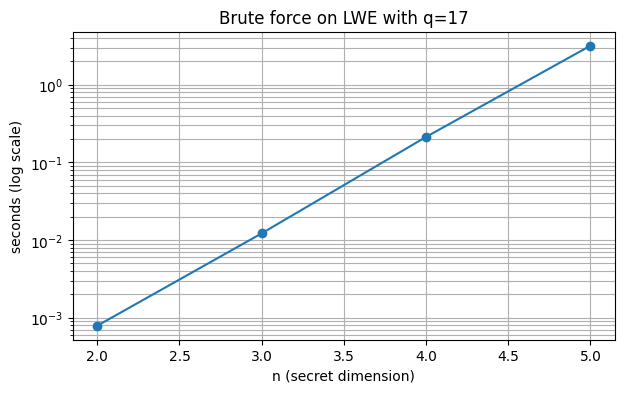

In [4]:
ns = [2, 3, 4, 5]
q = 17  # small q to keep the search space tiny
times = []
for n in ns:
    rng = np.random.default_rng(n)
    pk, sk = toy_keygen(n=n, q=q, sigma=0.5, rng=rng, m=4 * n)
    res = brute_force_secret(pk, error_tolerance=1, time_budget_s=30)
    ok = verify_secret(sk, res.secret)
    print(f'n={n}: {res.seconds:.3f}s, recovered={ok}')
    times.append(res.seconds)

plt.figure(figsize=(7, 4))
plt.semilogy(ns, times, 'o-')
plt.xlabel('n (secret dimension)')
plt.ylabel('seconds (log scale)')
plt.title(f'Brute force on LWE with q={q}')
plt.grid(True, which='both')
plt.show()

## 외삽

$n$이 $+1$ 될 때마다 탐색 공간은 $q$배로 곱해집니다. $n=5$가 $T$초 걸렸다면, $n=16$은 $T \cdot q^{11} = T \cdot 17^{11}$초가 걸릴 것입니다. $q=17$이면 대략 **350억 배** 더 느린 셈입니다.

ML-KEM의 실제 파라미터(유효 $n=256$, modulus $q=3329$)에서는 숫자가 천문학적입니다 — 고전 혹은 양자 하드웨어 어느 것이든 우주의 나이를 훨씬 뛰어넘는 시간이 필요합니다.

In [5]:
T_last = times[-1]
n_last = ns[-1]
n_target = 16
factor = q ** (n_target - n_last)
years = T_last * factor / (365.25 * 24 * 3600)
print(f'n={n_target} extrapolated: {years:.2e} years')

n=16 extrapolated: 3.46e+06 years


## 최신 공격 기법

실제 암호 해독은 **brute force보다 지수적으로 더 빠르지만** — 적절히 선택된 파라미터에 대해서는 여전히 차원에 대해 지수 시간입니다. 핵심 기법들은 다음과 같습니다.

- **BKZ lattice reduction** — 샘플들로부터 만든 격자에서 짧은 벡터를 찾습니다.
- **Primal / dual embedding** — LWE를 uSVP 또는 BDD 문제로 재구성합니다.
- **힌트를 이용한 dual attack** — 구조를 활용하는 현대적 변형.

**ML-KEM-512**의 경우, 알려진 최선의 공격 비용은 대략 $2^{143}$ 연산입니다. 구체적 난이도를 평가하는 표준 도구는 **LWE estimator** (Albrecht 외)입니다. 알려진 모든 공격을 추적하고 주어진 파라미터 집합에 대해 최선의 공격을 선택해 줍니다.

→ 다음: `04_polynomial_rings.ipynb` — ML-KEM을 빠르게 만드는 트릭.